# d17-40 Distance Metric Analysis

**What this notebook does:**
- Computes the inter-residue distance **d17-40** (GLY17–ASN40 distance) from GROMACS
  distance CSV files for all available simulations
- Converts GROMACS distances from nm to Å (1 nm = 10 Å)
- Plots the distance trace for each simulation, split into **Phase 1** and **Phase 2**
  using per-simulation phase boundaries stored in `PHASE_LIMIT_DICO`
- Saves a zoomed view showing only Phase 2
- Computes and exports descriptive statistics to CSV

**Background:**
d₄₀₋₁₇ measures the distance between ASP17 (chain B) and ASN40 (chain B), residue index
shifted by +99 → column `116_139` in the distance files).

**Sections:**
1. Install & import libraries
2. Configuration (paths, phase limits)
3. Helper function: `cal_d_17_40()`
4. Discover distance files
5. Plot all simulations (Phase 1 + Phase 2)
6. Plot zoomed view (Phase 2 only)
7. Compute and export statistics


In [1]:
# 1. Imports
import os
import math
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 2. Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 3. Configuration — adapt these paths to your environment
ROOTDIR    = '/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/'
OUTPUT_DIR = '/content/drive/MyDrive/M1_STAGE/Manips/'

os.chdir(ROOTDIR)

# Phase boundaries: frame index where Phase 1 ends and Phase 2 begins
PHASE_LIMIT_DICO = {
    'V7':  198,
    'V8':  180,
    'V21': 155,
    'V12': 35,
    'V11': 1000,
    'V1':  517,
}

title_font = {'fontsize': 14, 'fontweight': 'medium'}

In [5]:
# 4. Helper function — extract d17-40 from a distance DataFrame
def cal_d_17_40(distance_df: pd.DataFrame) -> pd.Series:
    """
    Return the d17-40 time series from a GROMACS distance file.
    Column '116_139' corresponds to chain B residues (ASP40 chB → index shifted).
    """
    return distance_df['116_139']

In [6]:
# 5. Discover all distance files (files starting with 'distance_')
distance_files_paths = []
for subdir, _, files in os.walk(ROOTDIR):
    for f in files:
        if f.startswith('distance_'):
            distance_files_paths.append(os.path.join(subdir, f))

distance_files_paths.sort()
print(f'Found {len(distance_files_paths)} distance file(s):')
for p in distance_files_paths:
    print(' ', os.path.basename(p))

Found 6 distance file(s):
  distance_V1.csv
  distance_V11.csv
  distance_V12.csv
  distance_V21.csv
  distance_V7.csv
  distance_V8.csv


In [7]:
# 6. Extract d17-40 once and cache in a dictionary
d17_40_cache = {}

for distance_file in distance_files_paths:
    sim_name = os.path.basename(distance_file).replace('distance_', '').replace('.csv', '')
    df = pd.read_csv(distance_file) * 10  # nm → Å
    d17_40_cache[sim_name] = df['116_139']

print(f'Cached d17-40 data for {len(d17_40_cache)} simulations')

Cached d17-40 data for 6 simulations


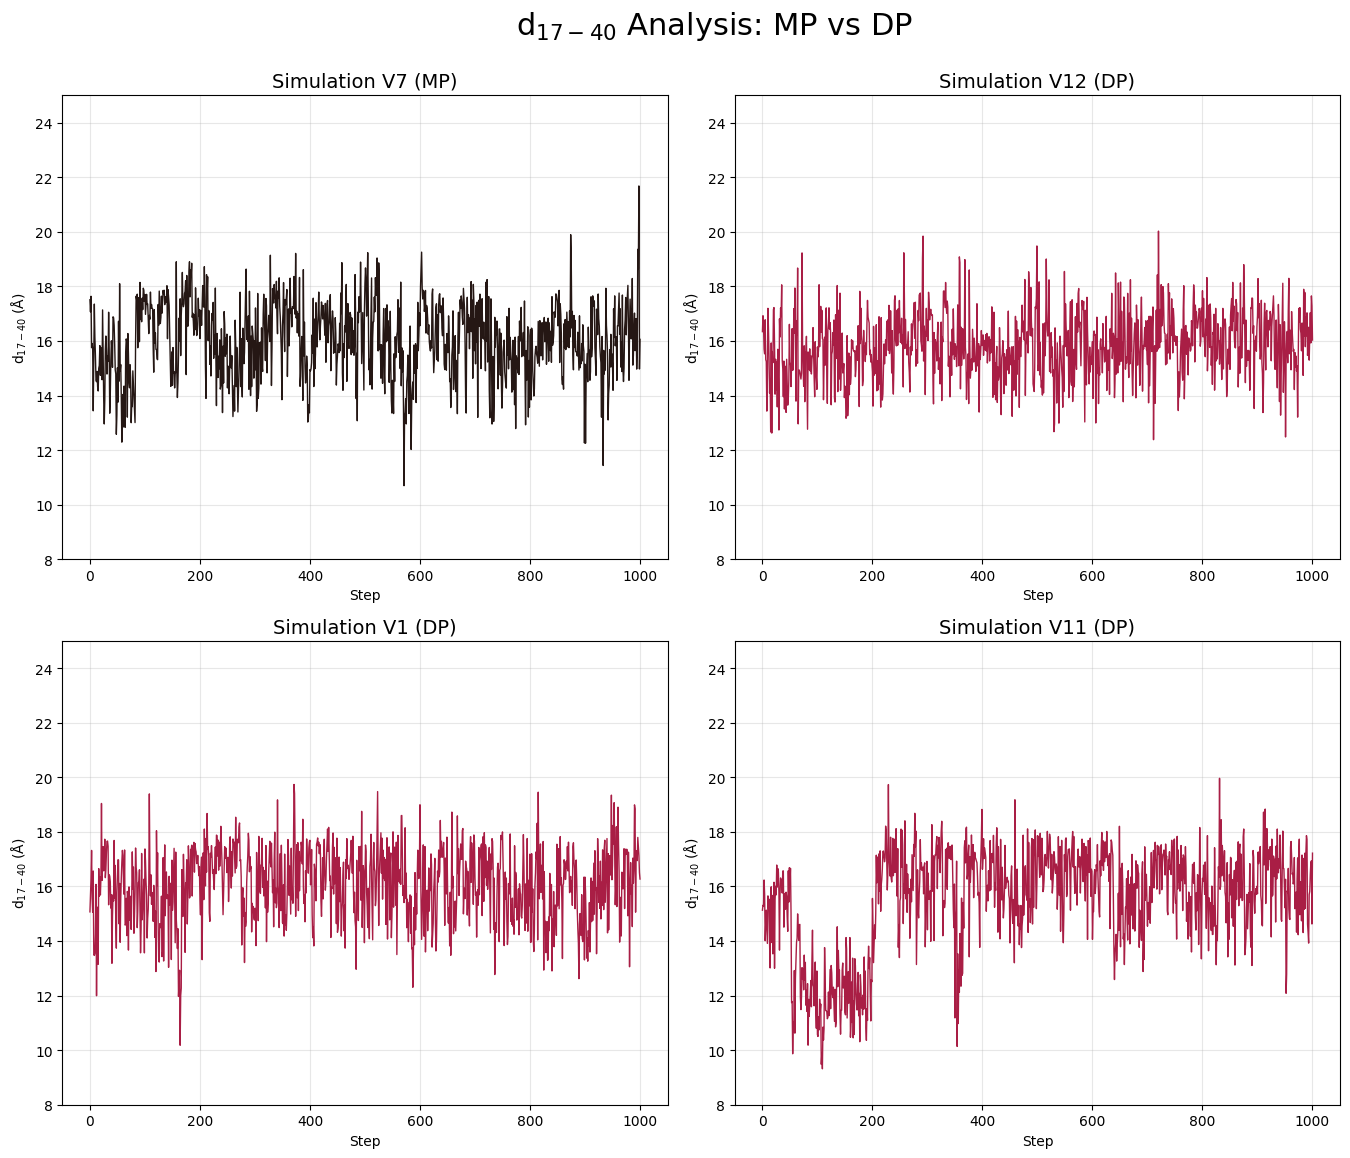

In [8]:
# 7. Plot d17-40 for all simulations — No phase separation
num_files = len(distance_files_paths)
num_cols  = 2
num_rows  = math.ceil(num_files / num_cols)

fig, axes = plt.subplots(num_rows, num_cols,
                          figsize=(num_cols * 8, num_rows * 6), squeeze=False)
axes = axes.flatten()
plot_idx = 0
line_mp = None
line_dp = None
fig.suptitle(r'd$_{17-40}$ Analysis: MP vs DP', fontsize=22, x=0.45, y=0.92)

path_dict = {os.path.basename(f).replace('distance_', '').replace('.csv', ''): f for f in distance_files_paths}
sim_order = ['V7','V12','V1','V11']
files_sorted = []
for name in sim_order:
    if name in path_dict:
        files_sorted.append(path_dict[name])

for plot_idx, distance_file in enumerate(files_sorted):
    ax = axes[plot_idx]
    sim_name = os.path.basename(distance_file).replace('distance_', '').replace('.csv', '')

    plot_color = "#251714FF" if sim_name == 'V7' else '#A91E45FF'
    condition_label = "MP" if sim_name == 'V7' else 'DP'
    
    d_series = d17_40_cache[sim_name]
    
    current_line, = ax.plot(d_series.index[:], d_series[:], color=plot_color, linewidth=1)

    if sim_name == 'V7':
        line_mp = current_line
    elif line_dp is None:
        line_dp = current_line

    ax.set_title(f'Simulation {sim_name} ({condition_label})', fontdict=title_font)
    ax.set_xlabel('Step')
    ax.set_ylabel(r'd$_{17-40}$ (Å)')
    ax.set_ylim(8, 25)
    ax.grid(True, alpha=0.3)

# Hide unused axes
for j in range(plot_idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 0.85, 0.92])
plt.show()
#fig.savefig(os.path.join(OUTPUT_DIR, 'Figures/d_17_40.png'), bbox_inches='tight', dpi=300)

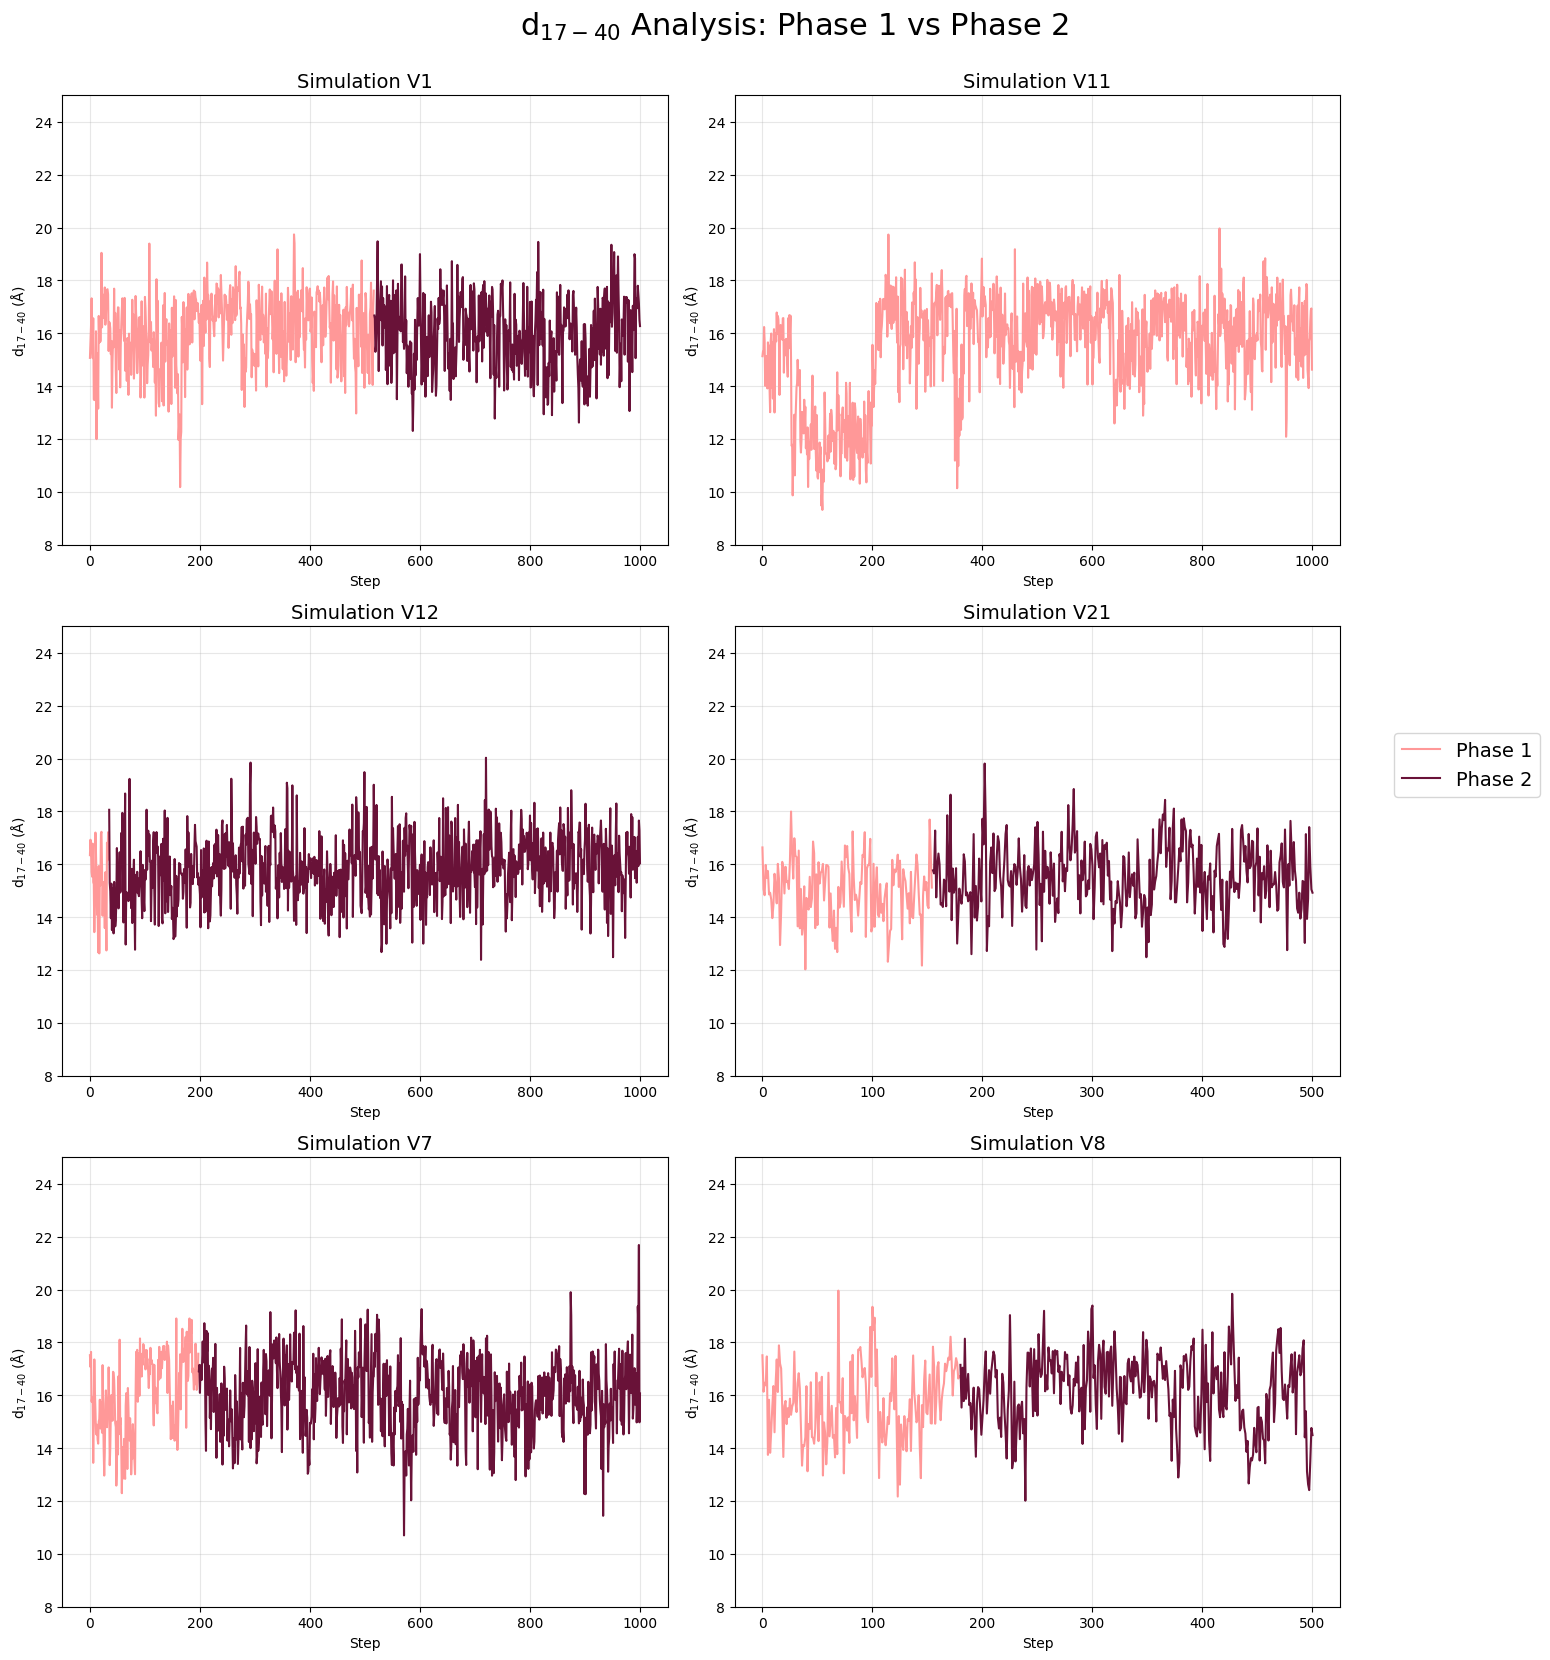

In [9]:
# 5. Plot d17-40 for all simulations — Phase 1 (pink) vs Phase 2 (cyan)
num_files = len(distance_files_paths)
num_cols  = 2
num_rows  = math.ceil(num_files / num_cols)

fig, axes = plt.subplots(num_rows, num_cols,
                          figsize=(num_cols * 8, num_rows * 6), squeeze=False)
axes = axes.flatten()
fig.suptitle(r'd$_{17-40}$ Analysis: Phase 1 vs Phase 2', fontsize=22, y=0.92)
line_ph1 =  None
line_ph2 = None

for plot_idx, distance_file in enumerate(distance_files_paths):
    ax = axes[plot_idx]
    sim_name = os.path.basename(distance_file).replace('distance_', '').replace('.csv', '')
    
    d_series = d17_40_cache[sim_name]
    phase_limit = PHASE_LIMIT_DICO.get(sim_name, len(d_series))
    
    line_ph1, = ax.plot(d_series.index[:phase_limit],  d_series[:phase_limit],
                        color='#FF9898FF', linewidth=1.5)
    line_ph2, = ax.plot(d_series.index[phase_limit:],  d_series[phase_limit:],
                        color='#691238FF', linewidth=1.5)
    ax.set_title(f'Simulation {sim_name}', fontdict=title_font)
    ax.set_xlabel('Step')
    ax.set_ylabel(r'd$_{17-40}$ (Å)')
    ax.set_ylim(8, 25)
    ax.grid(True, alpha=0.3)

# Hide unused axes
for j in range(plot_idx + 1, len(axes)):
    fig.delaxes(axes[j])

if line_ph1 and line_ph2:
    fig.legend(handles=[line_ph1, line_ph2], labels=['Phase 1', 'Phase 2'],
            loc='center', bbox_to_anchor=(0.92, 0.5),
            fontsize=14, frameon=True)

plt.tight_layout(rect=[0, 0, 0.85, 0.92])
plt.show()
fig.savefig(os.path.join(OUTPUT_DIR, 'Figures/d_17_40_phase_sep.png'), bbox_inches='tight', dpi=300)

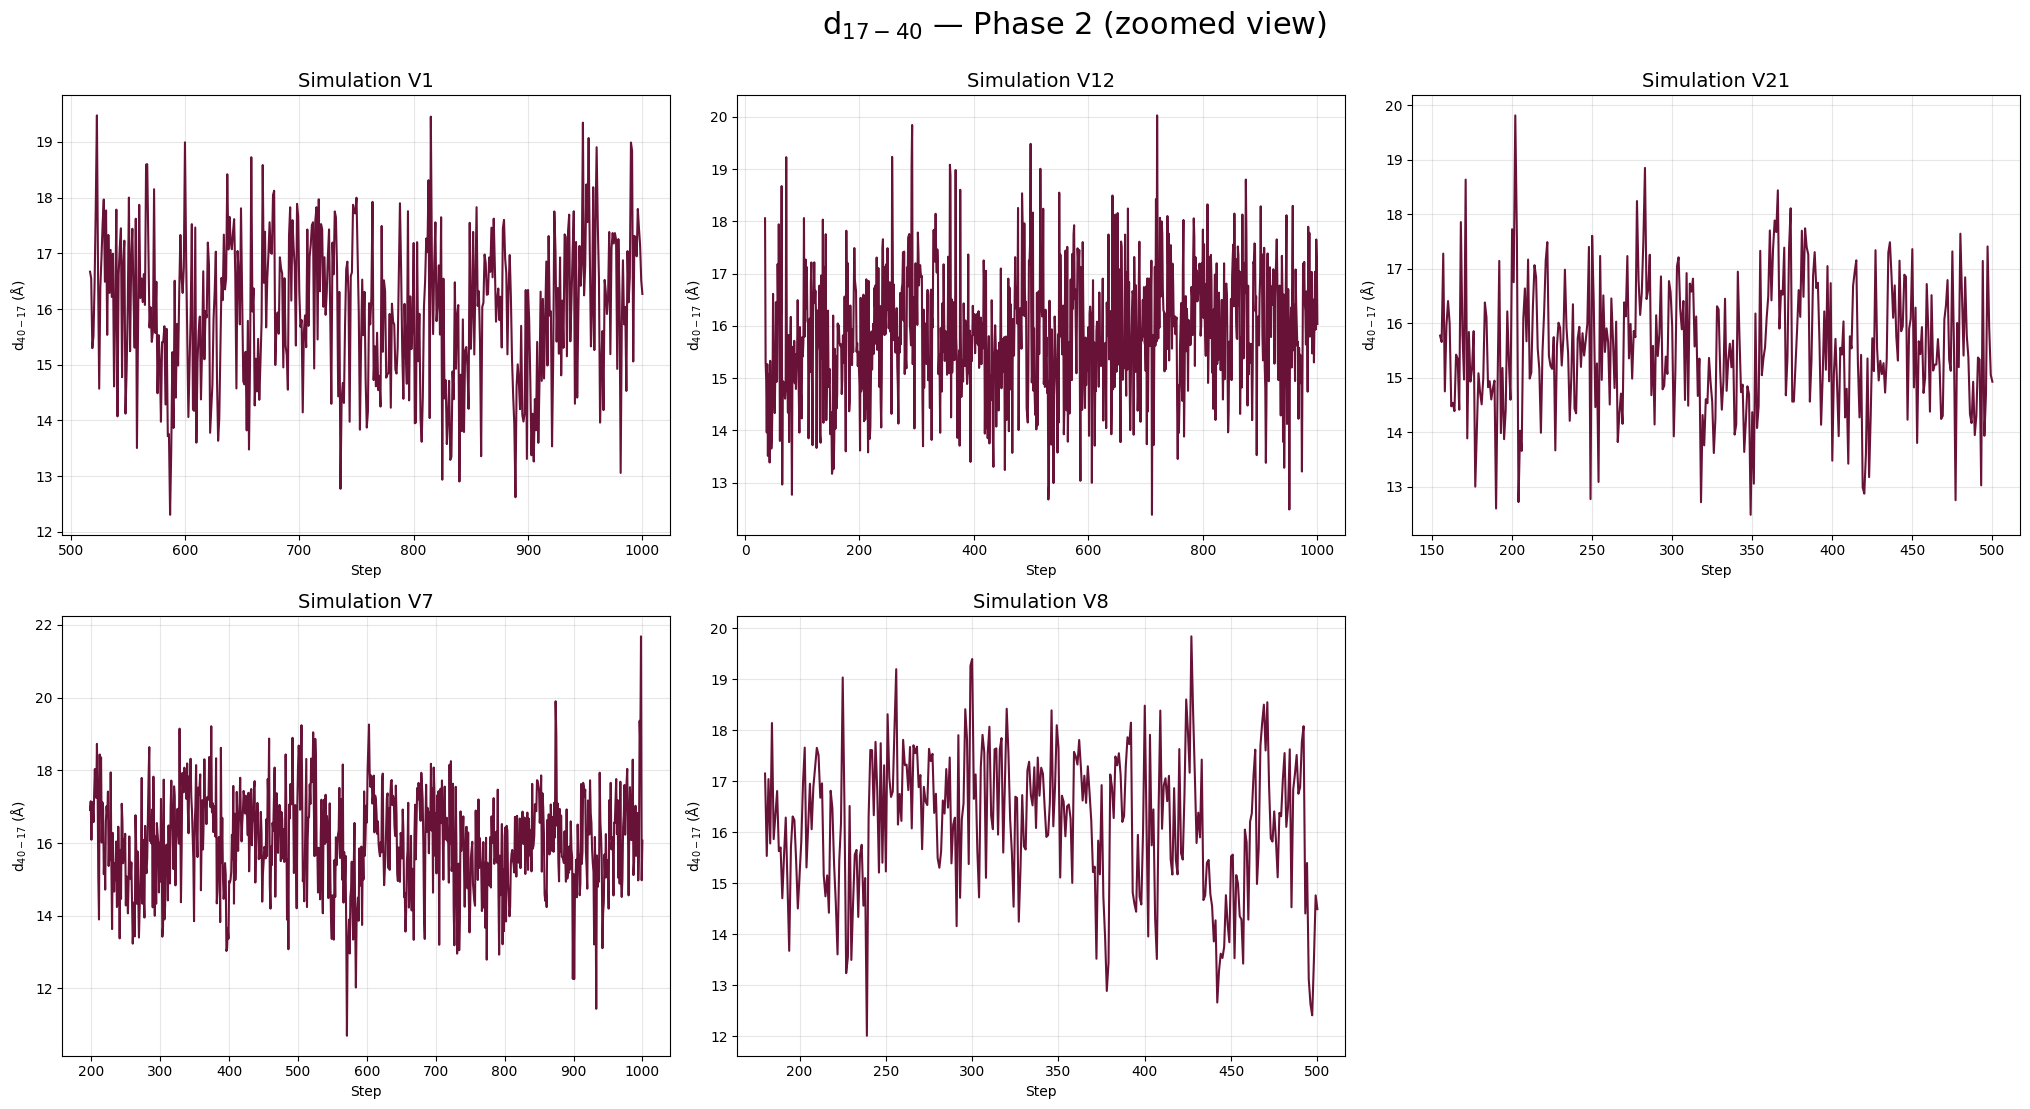

In [13]:
# 7. Zoomed plot — Phase 2 only
num_rows = 2
num_cols = 3

distance_files_paths = [path for path in distance_files_paths if not path.endswith('V11.csv')]

fig, axes = plt.subplots(num_rows, num_cols,
                          figsize=(num_cols * 8, num_rows * 6), squeeze=False)
axes = axes.flatten()
fig.suptitle(r'd$_{17-40}$ — Phase 2 (zoomed view)', fontsize=22, y=0.92, x=0.45)

for plot_idx, distance_file in enumerate(distance_files_paths):
    ax = axes[plot_idx]
    sim_name = os.path.basename(distance_file).replace('distance_', '').replace('.csv', '')

    d_series = d17_40_cache[sim_name]
    phase_limit = PHASE_LIMIT_DICO.get(sim_name, len(d_series))

    ax.plot(d_series.index[phase_limit:], d_series[phase_limit:],
            color='#691238FF', linewidth=1.5)
    ax.set_title(f'Simulation {sim_name}',fontdict=title_font)
    ax.set_xlabel('Step')
    ax.set_ylabel(r'd$_{40-17}$ (Å)')
    ax.grid(True, alpha=0.3)

for j in range(plot_idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 0.85, 0.92])
plt.show()
fig.savefig(os.path.join(OUTPUT_DIR, 'Figures/d_40_17_zoomed.png'), bbox_inches='tight', dpi=300)

In [14]:
# 7. Descriptive statistics per simulation — exported to CSV
summary_stats_dict = {}

for distance_file in distance_files_paths:
    sim_name = os.path.basename(distance_file).replace('distance_', '').replace('.csv', '')
    df = pd.read_csv(distance_file) * 10
    df.index.name = 'step'
    d_series = cal_d_40_17(df)
    summary_stats_dict[sim_name] = d_series.describe()

summary_stats_df = pd.DataFrame(summary_stats_dict)
summary_stats_df.to_csv(
    os.path.join(OUTPUT_DIR, 'Tables/d_40_17_stats.csv'),
    index=True, header=True, decimal='.', float_format='%.3f'
)
summary_stats_df

NameError: name 'cal_d_40_17' is not defined